#### What is Parallelization in LangGraph?
In LangGraph, nodes typically execute in a sequence defined by edges, but when tasks don’t depend on each other’s outputs, you can run them in parallel. This is achieved by:
- Defining multiple nodes that can operate independently.

- Connecting them to a common starting point (e.g., START or another node).

- Merging their outputs into a downstream node if needed.

LangGraph handles this implicitly when nodes are independent and can leverage multi-threading or asynchronous execution under the hood, depending on the runtime environment (e.g., Python’s asyncio or a multi-threaded executor).

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Graph State
class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

In [8]:
# Nodes
def generate_character(state: State):
    """Generate character descriptions"""
    msg = llm_groq.invoke(f"Create two character names and brief traits for a story about {state['topic']}")
    return {"characters": msg.content}

def generate_setting(state: State):
    """Generate a story setting"""
    msg = llm_groq.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings": msg.content}

def generate_premise(state: State):
    """Generate a story premise"""
    msg = llm_groq.invoke(f"Write a one-sentence plot premise for a story about {state['topic']}")
    return {"premises": msg.content}

def combine_elements(state: State):
    """Combine characters, setting and premise into a intro"""
    msg = llm_groq.invoke(
        f"Write a short story introduction using these elements: \n"
        f"Characters: {state['characters']}\n"
        f"Settings: {state['settings']}\n"
        f"Premise: {state['premises']}"
    )
    return {"story_intro": msg.content}

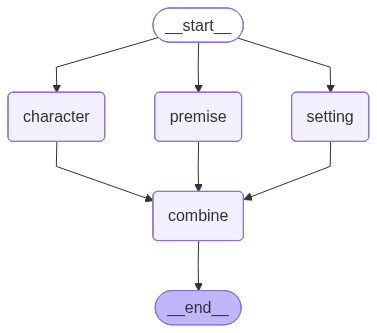

In [11]:
# Build the graph
graph = StateGraph(State)
graph.add_node("character", generate_character)
graph.add_node("setting", generate_setting)
graph.add_node("premise", generate_premise)
graph.add_node("combine", combine_elements)

# Define edges (parallel execution from START)
graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")
graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("combine", END)

# Combine and run
compiled_graph = graph.compile()
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [12]:
state = {"topic": "time travel"}
result = compiled_graph.invoke(state)
result

{'topic': 'time travel',
 'characters': '**1. Name:** *Elias Chronos*  \n**Traits:** A seasoned time traveler in his late 40s, Elias is a former historian who accidentally discovered time travel while studying ancient paradoxes. Cynical and weary from witnessing the same events repeat across centuries, he’s driven by a desperate need to fix a personal tragedy—a failed attempt to save his daughter’s life. He carries a pocket watch that malfunctions in different eras, symbolizing his fractured relationship with time. His strength lies in strategy, but his fatalism often clashes with more idealistic partners.  \n\n**2. Name:** *Lyra Vesper*  \n**Traits:** A 27-year-old quantum physicist with a reckless charm, Lyra invented the time-travel device as a graduate student. Idealistic to a fault, she sees time as a “river to be crossed,” not feared. Her impulsive curiosity lands her in dangerous paradoxes, but her quick wit and knowledge of temporal mechanics keep her a step ahead. Secretly, sh

#### Key Benefits
- Speed: Reduces total execution time by running tasks concurrently.

- Scalability: Handles larger workflows efficiently.

- Modularity: Keeps the graph structure clean and reusable.

#### Key Takeaways
- When to Parallelize: Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

- Merging: Downstream nodes can aggregate parallel results.

- LangGraph Support: The framework naturally supports this by waiting for all required inputs before proceeding.

